# SINR Layout Snapshot

This notebook draws two layout figures for one scene drop:

1. Initial `BS / TN / NTN` positions in the scene.
2. Final `used NTN / used TN` positions after strongest-BS-sector pairing and thresholding.
   TNs are marked with an outer circle colored by the paired BS (BS-level color only, not sector-level).


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sionna.rt import load_scene

import sinr_cdf_utils as scu
from SceneConfigSionna import SceneConfigSionna


In [2]:
scene_path = Path('/workspace/shizhen/NTN-NULLING-NONCOH/blender_scene_big/10km_times_10km/10km_times_10km.xml')
scene = load_scene(str(scene_path))

SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)

print(f'Scene loaded from: {scene_path}')


x range: [-5024.417, 5015.583]
y range: [-5047.131, 5042.869]
Scene loaded from: /workspace/shizhen/NTN-NULLING-NONCOH/blender_scene_big/10km_times_10km/10km_times_10km.xml


## Snapshot Parameters

Adjust these values, then run the notebook top to bottom.


In [3]:
# Deployment
ntn_rx = 100
tn_rx = 100
bs_row = 3
bs_col = 3
nsect = 3

azimuth = 120.0
elevation = 50.0

# Carrier and arrays
fc = 7e9
bandwidth_hz = 100e6
bs_tx_rows = 8
bs_tx_cols = 8
tn_rx_rows = 1
tn_rx_cols = 1

# BS sector orientation
sector_yaw_offset_deg = 0.0
sector_head_down_deg = 5.0
sector_roll_deg = 0.0
sector_yaw_offset_rad = np.deg2rad(sector_yaw_offset_deg)
sector_pitch_rad = -np.deg2rad(sector_head_down_deg)
sector_roll_rad = np.deg2rad(sector_roll_deg)

# One-drop scene generation
compute_positions_kwargs = dict(
    ntn_rx=ntn_rx,
    tn_rx=tn_rx,
    azimuth=azimuth,
    elevation=elevation,
    centerBS=False,
    bs_grid=(bs_row, bs_col),
    bs_boundary=1500,
    tn_building_ratio=0.6,
    tn_distance=400,
    ntn_building_ratio=0.6,
    plot_grid=False,
    plot_bs=False,
    plot_tn=False,
    plot_ntn=False,
)

compute_cir_kwargs = dict(
    nsect=nsect,
    fc=fc,
    tx_rows=bs_tx_rows,
    tx_cols=bs_tx_cols,
    tn_rx_rows=tn_rx_rows,
    tn_rx_cols=tn_rx_cols,
    max_depth=0,
    bandwidth=bandwidth_hz,
    tx_power_dbm=40,
    tn_tx_power_dbm=23,
    ntn_tx_power_dbm=25,
    ntn_tx_batch_size=100,
    sector_yaw_offset_rad=sector_yaw_offset_rad,
    sector_pitch_rad=sector_pitch_rad,
    sector_roll_rad=sector_roll_rad,
)

print(f'NTN={ntn_rx}, TN={tn_rx}, BS grid={bs_row}x{bs_col}, nsect={nsect}')
print(f'fc={fc/1e9:.2f} GHz, bandwidth={bandwidth_hz/1e6:.1f} MHz')


NTN=100, TN=100, BS grid=3x3, nsect=3
fc=7.00 GHz, bandwidth=100.0 MHz


In [4]:
# Powers and threshold
thermal_noise_density_dbm_hz = -174
bs_tx_power_dbm = float(compute_cir_kwargs['tx_power_dbm'])
tn_tx_power_dbm = float(compute_cir_kwargs['tn_tx_power_dbm'])
ntn_tx_power_dbm = float(compute_cir_kwargs['ntn_tx_power_dbm'])

bs_tx_power = 10 ** ((bs_tx_power_dbm - 30) / 10)

tn_nf_db = 7
bs_nf_db = 5

tn_noise_power_dbm = thermal_noise_density_dbm_hz + 10 * np.log10(bandwidth_hz) + tn_nf_db
bs_noise_power_dbm = thermal_noise_density_dbm_hz + 10 * np.log10(bandwidth_hz) + bs_nf_db

tn_noise_power = 10 ** ((tn_noise_power_dbm - 30) / 10)
bs_noise_power = 10 ** ((bs_noise_power_dbm - 30) / 10)

signal_threshold_db = -6
signal_channel_threshold = np.sqrt(
    10 ** (signal_threshold_db / 10) * bs_noise_power * (bs_tx_rows * bs_tx_cols) / bs_tx_power
)

print(f'BS TX power: {bs_tx_power_dbm:.1f} dBm')
print(f'TN noise power: {tn_noise_power_dbm:.2f} dBm')
print(f'Shared channel threshold: {signal_channel_threshold:.4e}')


BS TX power: 40.0 dBm
TN noise power: -87.00 dBm
Shared channel threshold: 1.4226e-06


In [5]:
SceneConfig.compute_positions(**compute_positions_kwargs)
cir_out = SceneConfig.compute_two_mode_cirs(**compute_cir_kwargs)

layout_data = scu.collect_two_mode_layout_plot_data(
    SceneConfig,
    cir_out['a_bs_to_tn'],
    h_ntn_to_tn=cir_out['a_ntn_to_tn'],
    h_ntn_to_bs=cir_out['a_ntn_to_bs'],
    h_tn_th=signal_channel_threshold,
    bs_tx_power=bs_tx_power,
    tn_noise_power=tn_noise_power,
)

print(f"Initial BS count: {layout_data['initial_bs_pos'].shape[0]}")
print(f"Initial TN count: {layout_data['initial_tn_pos'].shape[0]}")
print(f"Initial NTN count: {layout_data['initial_ntn_pos'].shape[0]}")
print(f"Paired / used TN count: {layout_data['used_tn_pos'].shape[0]}")
print(f"Used NTN count: {layout_data['used_ntn_pos'].shape[0]}")


Initial BS count: 9
Initial TN count: 100
Initial NTN count: 100
Paired / used TN count: 88
Used NTN count: 89


In [19]:
def plot_layout_map(
    scene_config,
    *,
    bs_pos,
    tn_pos,
    ntn_pos,
    tn_bs_idx=None,
    title,
    tn_label='TN',
    ntn_label='NTN',
):
    colors = ['lightgray', 'brown']
    cmap_bg = ListedColormap(colors)

    extent = scene_config.extent
    point_type = scene_config.point_type

    plt.figure(figsize=(7.4, 5.8))
    if extent is not None and point_type is not None:
        plt.imshow(point_type, cmap=cmap_bg, interpolation='nearest', extent=extent)

    cmap_bs = plt.get_cmap('tab10')
    n_bs = int(bs_pos.shape[0]) if bs_pos is not None else 0
    bs_colors = [cmap_bs(i % 10) for i in range(max(n_bs, 1))]

    bs_marker = (3, 0, -30)
    for i in range(n_bs):
        plt.scatter(
            bs_pos[i, 0],
            bs_pos[i, 1],
            c=[bs_colors[i]],
            marker=bs_marker,
            s=160,
            linewidths=1.5,
            label=f'BS {i}',
        )

    if tn_pos is not None and tn_pos.size > 0:
        plt.scatter(tn_pos[:, 0], tn_pos[:, 1], color='green', marker='x', s=28, label=tn_label)

    if ntn_pos is not None and ntn_pos.size > 0:
        plt.scatter(ntn_pos[:, 0], ntn_pos[:, 1], color='blue', marker='x', s=22, label=ntn_label)

    if tn_bs_idx is not None and tn_pos is not None and tn_pos.size > 0:
        for i in range(tn_pos.shape[0]):
            bs_id = int(tn_bs_idx[i])
            plt.scatter(
                tn_pos[i, 0],
                tn_pos[i, 1],
                edgecolors=bs_colors[bs_id % len(bs_colors)],
                facecolors='none',
                marker='o',
                s=160,
                linewidths=1.6,
            )

    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1.02), fontsize=9, frameon=True)
    plt.tight_layout()
    plt.show()


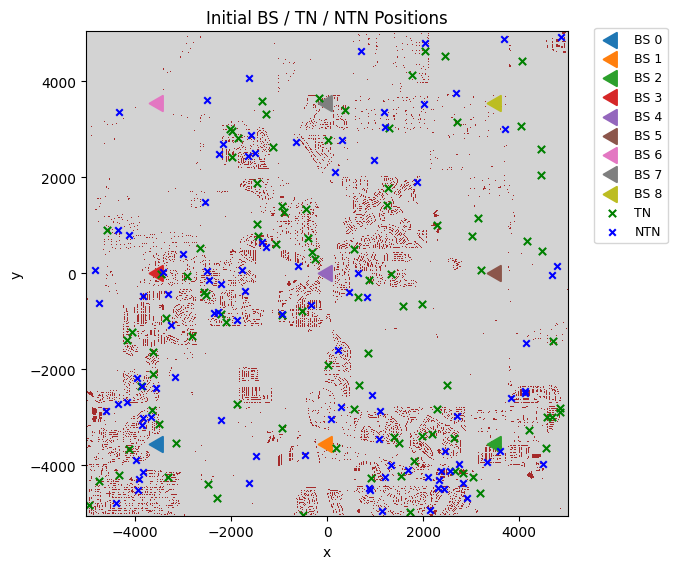

In [20]:
plot_layout_map(
    SceneConfig,
    bs_pos=layout_data['initial_bs_pos'],
    tn_pos=layout_data['initial_tn_pos'],
    ntn_pos=layout_data['initial_ntn_pos'],
    title='Initial BS / TN / NTN Positions',
)


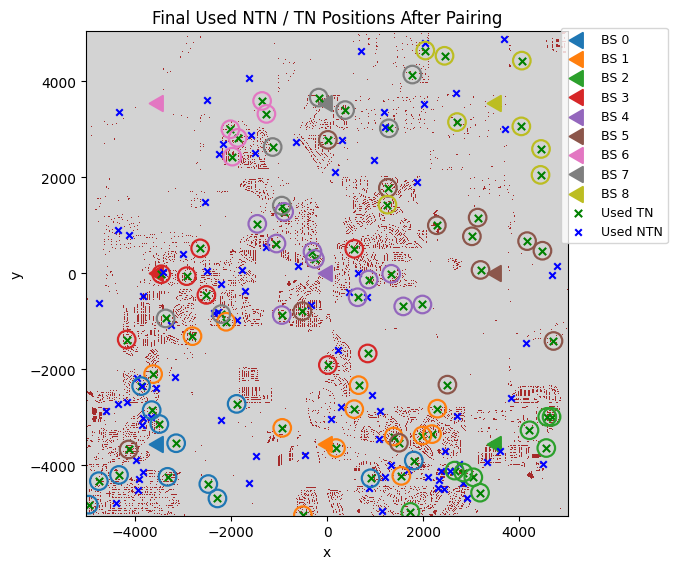

In [21]:
plot_layout_map(
    SceneConfig,
    bs_pos=layout_data['initial_bs_pos'],
    tn_pos=layout_data['used_tn_pos'],
    ntn_pos=layout_data['used_ntn_pos'],
    tn_bs_idx=layout_data['used_bs_idx'],
    title='Final Used NTN / TN Positions After Pairing',
    tn_label='Used TN',
    ntn_label='Used NTN',
)
